# Initial Setup

In [48]:
# Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Change numerical display format
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [49]:
# Load Dataset
data = pd.read_csv('PBL_DA_CAPSTONE_DATA.csv')

# Preview dataset
data.head()

,Audience Segment,Creative Size,Creative Messaging,Location,App/URL,Exchange,Device Make,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost
0,Online Behavior>United States>Validated Demogr...,300x250,Subscribe Today - 10% Discount,"Los Angeles, California",abcnews.go.com,Google Ad Manager,Apple PC,10524,55,7601,10242,11,6136.1339
1,Online Behavior>United States>Finance » Financ...,320x50,Sign up Today - 10% Off,"Orlando-Daytona Beach, Florida",accuweather.com,PubMatic,Smartphone,18324,60,3145,13703,8,6996.2318
2,Online Behavior>United States>Hobbies and Leis...,300x250,Subscribe Today - 10% Discount,"San Francisco, California",accuweather.com,Google Ad Manager,Smartphone,7862,20,2152,6039,2,6506.4337
3,Online Behavior>United States>Intent » Auto Bu...,300x250,Sign up Now - 10% Off,"Grand Rapids-Kalamazoo, Michigan",accuweather.com,Xandr - Monetize SSP (AppNexus),Smartphone,10501,90,4126,7654,8,6244.5179
4,Online Behavior>United States>Beauty and Fitne...,300x250,Sign up Now - 10% Off,"Chicago, Illinois",accuweather.com,Magnite DV+,Apple PC,23156,73,4468,18821,15,6173.4129


# Checking for missing values

In [50]:
# Number of missing values for each column
data.isna().sum()

Audience Segment          0
Creative Size             0
Creative Messaging        0
Location                  0
App/URL                   0
Exchange                  0
Device Make               0
Impressions               0
Clicks                    0
Viewable Impressions      0
Measurable Impressions    0
Total Conversions         0
Gross Cost                0
dtype: int64

# Reformatting values

In [51]:
# Show rows containing `»`
data[data['Audience Segment'].str.contains(r'\s*»\s*', regex=True)].head()

,Audience Segment,Creative Size,Creative Messaging,Location,App/URL,Exchange,Device Make,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost
0,Online Behavior>United States>Validated Demogr...,300x250,Subscribe Today - 10% Discount,"Los Angeles, California",abcnews.go.com,Google Ad Manager,Apple PC,10524,55,7601,10242,11,6136.1339
1,Online Behavior>United States>Finance » Financ...,320x50,Sign up Today - 10% Off,"Orlando-Daytona Beach, Florida",accuweather.com,PubMatic,Smartphone,18324,60,3145,13703,8,6996.2318
2,Online Behavior>United States>Hobbies and Leis...,300x250,Subscribe Today - 10% Discount,"San Francisco, California",accuweather.com,Google Ad Manager,Smartphone,7862,20,2152,6039,2,6506.4337
3,Online Behavior>United States>Intent » Auto Bu...,300x250,Sign up Now - 10% Off,"Grand Rapids-Kalamazoo, Michigan",accuweather.com,Xandr - Monetize SSP (AppNexus),Smartphone,10501,90,4126,7654,8,6244.5179
4,Online Behavior>United States>Beauty and Fitne...,300x250,Sign up Now - 10% Off,"Chicago, Illinois",accuweather.com,Magnite DV+,Apple PC,23156,73,4468,18821,15,6173.4129


In [52]:
# Replace `»` with `>` using REGEX
data['Audience Segment'] = data['Audience Segment'].str.replace(r'\s*»\s*', '>', regex=True)

## Checking data types

In [53]:
# Check data types of variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Audience Segment        727 non-null    object 
 1   Creative Size           727 non-null    object 
 2   Creative Messaging      727 non-null    object 
 3   Location                727 non-null    object 
 4   App/URL                 727 non-null    object 
 5   Exchange                727 non-null    object 
 6   Device Make             727 non-null    object 
 7   Impressions             727 non-null    object 
 8   Clicks                  727 non-null    int64  
 9   Viewable Impressions    727 non-null    object 
 10  Measurable Impressions  727 non-null    object 
 11  Total Conversions       727 non-null    int64  
 12  Gross Cost              727 non-null    float64
dtypes: float64(1), int64(2), object(10)
memory usage: 74.0+ KB


## Creating subset

In [54]:
#m Drop columns irrelevant to role
df_subset = data.drop(['Exchange'], axis=1)

In [55]:
# Add currency type to 'Gross Cost'
df_subset['Gross Cost'] = df_subset['Gross Cost'].round(2)
df_subset = df_subset.rename(columns={'Gross Cost': 'Gross Cost ($)'})

# Convert specific columns to integer type
cols_to_int = ['Impressions', 'Viewable Impressions', 'Measurable Impressions']
df_subset[cols_to_int] = df_subset[cols_to_int].replace(r'[^0-9.]', '', regex=True).astype(int)

df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Audience Segment        727 non-null    object 
 1   Creative Size           727 non-null    object 
 2   Creative Messaging      727 non-null    object 
 3   Location                727 non-null    object 
 4   App/URL                 727 non-null    object 
 5   Device Make             727 non-null    object 
 6   Impressions             727 non-null    int32  
 7   Clicks                  727 non-null    int64  
 8   Viewable Impressions    727 non-null    int32  
 9   Measurable Impressions  727 non-null    int32  
 10  Total Conversions       727 non-null    int64  
 11  Gross Cost ($)          727 non-null    float64
dtypes: float64(1), int32(3), int64(2), object(6)
memory usage: 59.8+ KB


# Classifying audience segments

In [56]:
RULES = [
    
    ("Other", [
        "no input", "yes", "i was", "subscribers", "management", "other"
    ]),

    # ── Automotive ───────────────────────────────────────────────────────────
    ("Automotive", [
        "auto buyers",
        "auto>auto car purchase",
        "auto>decision maker",
        "purchasing vehicles or automobile",
        "autos and vehicles", ">auto>", "automobile", "automotive",
        # Brands — bounded/unique enough to be safe
        "acura", "aston martin",
        "audi q",            # "Audi Q" series; "audi " also safe below
        " audi ",            # standalone word, avoids "auditing"
        "bmw", "bugatti", "buick", "cadillac",
        "caravan", "carpooling", "citroen", "crossover",
        "dodge",
        "electric and plug-in",
        "ferrari", "fiat",
        " ford ",            # space-padded; avoids "stanford", "oxford", "afford"
        "ford credit",       # catches "Ford Credit Buyer Propensity"
        "fuel economy",
        "gm-daewoo", "honda",
        "hybrid and alternative vehicle",
        "hyundai", "isuzu", "jaguar", "jeep", "kia",
        "landrover", "lexus", "lincoln heritage",
        "maserati", "maybach",
        "mazda",             # unique brand, safe
        "mercedes", "mitsubishi", "motorcycle",
        " mini ",            # space-padded; avoids "minimal", "minimize"
        "nissan", "opel", "peugeot", "pontiac", "porsche",
        "pre-owned", "rolls-royce", "saab",
        " seat ",            # space-padded; avoids "seasonal", "seated"
        "sedan", "sport car", "subaru", "toyota",
        " truck", " suv", " van ",
        "vauxhall", "vehicle", "vehicle parts", "volkswagen", "volvo",
        "auto parts store", "auto make defect", "company car",
    ]),
 
    # ── Finance and Insurance ─────────────────────────────────────────────────
    ("Finance and Insurance", [
        "finance", "financial", "insurance", "banking", "investing",
        "credit", "lending", "accounting", "tax",
        "loan", "mortgage", "stocks", "bonds", "derivatives",
        "commodities", "futures trading",
        "brokerage", "day trading",
        "asset and portfolio", "estate planning", "inheritance",
        "retirement", "pension",
        "savings account", "debit and checking",
        "money transfer", "wire service",
        "personal budgeting", "personal finance",
        "bookkeeping",
        "atm", "branch location",
        "massmutual", "new york life", "northwestern mutual",
        "transamerica", "aetna", "humana", "unitedhealth",
    ]),
 
    # ── Demographics ──────────────────────────────────────────────────────────
    ("Demographics", [
        "validated demographic", "demographic", "sociodemographic",
        ">age>", ">demo>",
        "females 1", "females 2", "females 3", "females 4",
        "females 5", "females 6", "females 25 or", "females 65",
        "males 1", "males 2", "males 3", "males 4",
        "males 5", "males 6", "males 25 or", "males 55", "males 65",
        "female head", "male head",
        "non-hispanic", "household income",
        "households with",
    ]),

    # ── Beauty and Fashion ────────────────────────────────────────────────────
    ("Beauty and Fashion", [
        "beauty", "fashion", "style", "hair", "skin", "cosmetic",
        "make-up", "makeup", "nail care", "body art",
        "clothing shopper", "spas", "cosmetology",
        "ulta", "mary kay", "bare escentuals",
        "unwanted body", "facial hair removal",
        "cosmetics", "cosmetics",
    ]),
 
    # ── Health and Wellness ───────────────────────────────────────────────────
    ("Health and Wellness", [
        "health", "wellness", "wellbeing", "telehealth",
        "fitness",           
        "weight loss", "yoga", "pilates",
        "massage therapy", "home exercise",
        "hygiene", "toiletries", "bodybuilding",
        "gyms", "health club", "healthy living",
    ]),
 
    # ── Sports ────────────────────────────────────────────────────────────────
    ("Sports", [
        "sports", "nfl", "nba", "mlb", "nhl", "nascar", "ufc",
        "pga ", "ncaa", "olympics",
        "premier league", "rugby",
        "american football", "football (american)",
        "baseball", "basketball", "volleyball",
        "soccer", "tennis", "racquet", "golf", "cycling",
        "skiing", "snowboard", "surfing", "boating", "kayaking",
        "fishing", "hunting enthusiast", "equestrian",
        "bowling", "ice skating", "skate sport",
        "track and field", "running and walking", "avid runner",
        "hiking", "camping", "water activities",
        "extreme sport", "combat sport",
        "live sporting", "sporting good",
        "motor sport", "motorsport",
    ]),
 
    # ── Travel and Leisure ────────────────────────────────────────────────────
    ("Travel and Leisure", [
        "travel", "tourism",
        " hotel", "hotel ",   # space-bounded to avoid edge cases
        "airline", "cruise", "flight",
        "vacation", "resort",
        "beach", "island",
        "ski traveler", "mountain and ski resort",
        "tourist", "theme park", "historical site",
        "regional park", "lakes and rivers",
        "graduation trip", "holidays and seasonal",
        "foreign vacationer",
        "zoos", "aquarium",
    ]),
 
    # ── Food and Dining ───────────────────────────────────────────────────────
    ("Food and Dining", [
        "food", "drink", "restaurant", "beverage", "cooking", "dining",
        "dessert", "cuisine", "beer", "wine", "spirits", "coffee",
        "juice", "bottled water", "soft drink", "fast food",
        "outback", "buffalo wild wings", "chilis", "five guys",
        "krispy kreme", "moes", "red lobster",
    ]),

    # ── News, Politics and Society ────────────────────────────────────────────
    ("News, Politics and Society", [
        "news", "politics", "government", "legal", "military",
        "natural disaster", "social justice", "current affairs",
    ]),
 
    # ── Media, Entertainment and Gaming ──────────────────────────────────────
    ("Media, Entertainment and Gaming", [
        "media", "entertainment",
        "music", " movies", "movie ",
        " tv ", "television", "gaming",
        " games", "game ", "streaming",
        "comics", "animation", "drama", "film festival",
        "fine art", "cultural arts", "arts enthusiast",
        "photography", "cameras and photo",
        "hip hop", "rap", "classic rock",
        "e-book", "gossip", "celebrity",
        "premium magazine", "game show",
        "audio",   # "music and audio", "streaming audio" — safe now "audi" is bounded
    ]),
 
    # ── Home and Real Estate ──────────────────────────────────────────────────
    # "rent" removed — too broad; use specific phrases only
    ("Home and Real Estate", [
        "real estate", "homeowner", "dwelling",
        "renter", "rental",
        "sensible rent", "highest rent", "lowest rent",
        "apartments and residential",
        "home and garden", "home improvement", "kitchen", "furniture",
        "home office", "lawn and garden", "home renovation",
        "home entertaining", "home learning",
        "diy", "property type", "home buying",
        "home appliance", "home furnishing", "home supply",
        "home renovator", "homemaking", "interior decor",
        "bed and bath", "yard and patio", "cozy outdoor living",
        "spring clean", "gardening shopper", "home entertainer",
        "house and garden", "multi-family dwelling",
    ]),
 
    # ── Technology ────────────────────────────────────────────────────────────
    ("Technology", [
        "technology", "telecom", "computing",
        "software", "electronics",
        "computer hardware", "computer software", "computers, laptop",
        "mobile phone", "mobile device", "mobile and wireless",
        "wireless provider",
        "tablet", "iphone",
        "huawei", "vivo", "zte",
        "web app", "web portal", "web service",
        "search engine", "email and messaging",
        "consumer electronics",
        "electronics & gadget", "electronics and gadget",
        "connected tv", "over-the-top",
        "internet connection", "internet service", "internet technology",
        "computer and video",   # "Computer and Video Games" — caught here before Gaming
    ]),
 
    # ── Family and Life Stages ────────────────────────────────────────────────
    ("Family and Life Stages", [
        "people and society", "life event",
        "family", "seniors",
        "millennials",
        "new parent", " parents", "parents ",   # bounded; avoids "rent" in "parents"
        "baby", "toddler", "infant",
        "moms", "bride", "engagement", "wedding",
        "movers", "single-family", "happy at home",
    ]),
 
    # ── Shopping and Retail ───────────────────────────────────────────────────
    ("Shopping and Retail", [
        "shopping", "purchase", "buyer", "retail", "transactional",
        "impulse-shopper", "price-driven", "quality-first",
        "made in america", "buying channel", "response performance",
        "direct marketing", "composite segment",
        "luxury store", "luxury home goods",
        "young adult clothing",
        "online shopper", "ecommerce", "online retailer",
        "loyalty card",
        "luxury", "luxurious brand", "in-market",
        "cvs", "walgreens", "old navy", "drug store",
        "continuity buyer", "us mail order",
    ]),
 
    # ── B2B and Business ──────────────────────────────────────────────────────
    ("B2B and Business", [
        "b2b", "business", "economy", "oil & gas", "oil and gas",
        "advertising service", "marketing or market research",
        "office supplies", "office supply",
    ]),
 
    # ── Education and Careers ─────────────────────────────────────────────────
    ("Education and Careers", [
        "education", "careers", "student", "occupation",
        "teacher", "architect", "engineer", "programmer",
        "entrepreneur", "job search",
        "college application", "college graduation",
        "university graduation",
        "study grant", "scholarship",
        "officemanager", "propertymanager",
        "supplychainmanager", "systemsanalyst",
        " sales",   # space-padded to avoid "resales", "wholesale" etc.
        "bookkeeping",
    ]),
 
    # ── Pets ──────────────────────────────────────────────────────────────────
    ("Pets", [
        "pet", "animals", "cat owner", "dog",
    ]),
 
    # ── Lifestyle and Social ──────────────────────────────────────────────────
    ("Lifestyle and Social", [
        "social network", "online communit", "social life", "dating",
        "blogging", "photo and video sharing", "file sharing",
        "life stage", "society", "green consumer", "rural improvement",
        "women born to shop", "the changing consumer",
        "bars, clubs", "nightlife", "clubs and organization",
        "party planning", "events and attraction",
        "expos and convention", "virtual events",
        "contributes by volunteering", "contributes to charities",
        "contests, awards",
    ]),
]
 
 
def classify_segment(value: str) -> str:
    v = value.lower()
    for category, triggers in RULES:
        if any(t in v for t in triggers):
            return category
    return "Other"

In [57]:
# Format string split and create new columns
segment = df_subset['Audience Segment'].apply(classify_segment).tolist()
detail = df_subset['Audience Segment'].str.split('>').str[-1]

df_subset.insert(loc=1, column='Segment Type', value=segment)
df_subset.insert(loc=2, column='Segment Detail', value=detail)

df_subset.head()

,Audience Segment,Segment Type,Segment Detail,Creative Size,Creative Messaging,Location,App/URL,Device Make,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost ($)
0,Online Behavior>United States>Validated Demogr...,Demographics,Females 25 or older,300x250,Subscribe Today - 10% Discount,"Los Angeles, California",abcnews.go.com,Apple PC,10524,55,7601,10242,11,6136.1300
1,Online Behavior>United States>Finance>Financia...,Other,Retirement and Pension,320x50,Sign up Today - 10% Off,"Orlando-Daytona Beach, Florida",accuweather.com,Smartphone,18324,60,3145,13703,8,6996.2300
2,Online Behavior>United States>Hobbies and Leis...,Sports,Equestrian,300x250,Subscribe Today - 10% Discount,"San Francisco, California",accuweather.com,Smartphone,7862,20,2152,6039,2,6506.4300
3,Online Behavior>United States>Intent>Auto Buye...,Automotive,Audi Q,300x250,Sign up Now - 10% Off,"Grand Rapids-Kalamazoo, Michigan",accuweather.com,Smartphone,10501,90,4126,7654,8,6244.5200
4,Online Behavior>United States>Beauty and Fitne...,Beauty and Fashion,Fitness Instruction and Personal Training,300x250,Sign up Now - 10% Off,"Chicago, Illinois",accuweather.com,Apple PC,23156,73,4468,18821,15,6173.4100


## List of segment types

In [62]:
# Counts by segment type
df_subset['Segment Type'].value_counts()

Segment Type
Automotive                         80
Media, Entertainment and Gaming    79
Finance and Insurance              64
Demographics                       63
Sports                             63
Travel and Leisure                 59
Shopping and Retail                43
Beauty and Fashion                 42
Food and Dining                    39
Technology                         34
Home and Real Estate               34
Other                              28
B2B and Business                   27
News, Politics and Society         23
Lifestyle and Social               18
Family and Life Stages             15
Pets                                7
Education and Careers               5
Health and Wellness                 4
Name: count, dtype: int64

# Calculating metrics

In [59]:
# Calculate viewability
df_subset['Viewability'] = df_subset['Viewable Impressions'] / df_subset['Measurable Impressions']

# Calculate CTR (Click Through Rate)
df_subset['CTR'] = df_subset['Clicks'] / df_subset['Impressions']

# Calculate vCTR (Viewable Click Through Rate)
df_subset['vCTR'] = df_subset['Clicks'] / df_subset['Viewable Impressions']

# Calculate CVR (Conversion Rate)
df_subset['CVR'] = np.where(df_subset['Clicks'] > 0, df_subset['Total Conversions'] / df_subset['Clicks'], 0)

# Calculate CPC (Cost Per Click)
df_subset['CPC ($)'] = np.where(df_subset['Clicks'] > 0, df_subset['Gross Cost ($)'] / df_subset['Clicks'], 0).round(2)

# Calculate CPM (Cost Per Mille)
df_subset['CPM ($)'] = (df_subset['Gross Cost ($)'] / (df_subset['Impressions'] / 1000)).round(2)

# Calculate eCPA (Effective Cost Per Acquisition)
df_subset['CPA ($)'] = (df_subset['CPC ($)'] / df_subset['CVR']).round(2)

## Previewing updated subset

In [60]:
df_subset.head()

,Audience Segment,Segment Type,Segment Detail,Creative Size,Creative Messaging,Location,App/URL,Device Make,Impressions,Clicks,...,Measurable Impressions,Total Conversions,Gross Cost ($),Viewability,CTR,vCTR,CVR,CPC ($),CPM ($),CPA ($)
0,Online Behavior>United States>Validated Demogr...,Demographics,Females 25 or older,300x250,Subscribe Today - 10% Discount,"Los Angeles, California",abcnews.go.com,Apple PC,10524,55,...,10242,11,6136.1300,0.7421,0.0052,0.0072,0.2000,111.5700,583.0600,557.8500
1,Online Behavior>United States>Finance>Financia...,Other,Retirement and Pension,320x50,Sign up Today - 10% Off,"Orlando-Daytona Beach, Florida",accuweather.com,Smartphone,18324,60,...,13703,8,6996.2300,0.2295,0.0033,0.0191,0.1333,116.6000,381.8100,874.5000
2,Online Behavior>United States>Hobbies and Leis...,Sports,Equestrian,300x250,Subscribe Today - 10% Discount,"San Francisco, California",accuweather.com,Smartphone,7862,20,...,6039,2,6506.4300,0.3564,0.0025,0.0093,0.1000,325.3200,827.5800,3253.2000
3,Online Behavior>United States>Intent>Auto Buye...,Automotive,Audi Q,300x250,Sign up Now - 10% Off,"Grand Rapids-Kalamazoo, Michigan",accuweather.com,Smartphone,10501,90,...,7654,8,6244.5200,0.5391,0.0086,0.0218,0.0889,69.3800,594.6600,780.5200
4,Online Behavior>United States>Beauty and Fitne...,Beauty and Fashion,Fitness Instruction and Personal Training,300x250,Sign up Now - 10% Off,"Chicago, Illinois",accuweather.com,Apple PC,23156,73,...,18821,15,6173.4100,0.2374,0.0032,0.0163,0.2055,84.5700,266.6000,411.5700


## Summary

In [61]:
df_subset.describe()

,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost ($),Viewability,CTR,vCTR,CVR,CPC ($),CPM ($),CPA ($)
count,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,727.0000,721.0000
mean,117889.0151,320.6314,57629.5612,102025.7290,11.6561,3815.5061,0.5314,0.0036,0.0128,0.1096,52.1950,162.8701,697.4332
std,298271.7648,697.9901,172437.2006,258767.1393,15.5565,2206.5516,0.2155,0.0018,0.0258,0.1896,83.9336,191.6880,945.3426
min,7229.0000,0.0000,191.0000,2054.0000,1.0000,1247.0000,0.0123,0.0000,0.0000,0.0000,0.0000,1.8000,18.4600
25%,14024.5000,60.0000,5818.0000,11904.0000,4.0000,1663.1650,0.4095,0.0025,0.0047,0.0297,10.6700,33.2050,242.0700
50%,29834.0000,101.0000,12405.0000,24752.0000,8.0000,2921.1100,0.5629,0.0030,0.0071,0.0627,24.8400,100.4400,451.2000
75%,88396.0000,240.0000,37240.5000,75814.0000,14.0000,5987.2100,0.7015,0.0041,0.0123,0.1200,59.1000,197.2800,717.6000
max,4154911.0000,8745.0000,2338732.0000,3445626.0000,154.0000,8187.1100,0.9342,0.0159,0.4398,1.9796,785.1400,942.4000,6407.6200


# Total conversions analysis

In [66]:
# Top 15 Segment Types by number of Total Viewable Impressions
conversions = df_subset[df_subset['Segment Type'] != 'Other'].groupby('Segment Type')['Total Conversions'].sum().sort_values(ascending=False).reset_index()

conversions

,Segment Type,Total Conversions
0,Finance and Insurance,1160
1,Automotive,986
2,Travel and Leisure,911
3,Demographics,716
4,Sports,700
5,"Media, Entertainment and Gaming",613
6,Beauty and Fashion,511
7,Family and Life Stages,387
8,Food and Dining,374
9,Shopping and Retail,356


In [17]:
# Filter df_subset by remaining segment types in viewable_impressions_subset
df_subset = df_subset[df_subset['Segment Type'].isin(conversions_subset['Segment Type'])]

In [67]:
# Set global font for charts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Century Gothic', 'CenturyGothic', 'AppleGothic', 'sans-serif']

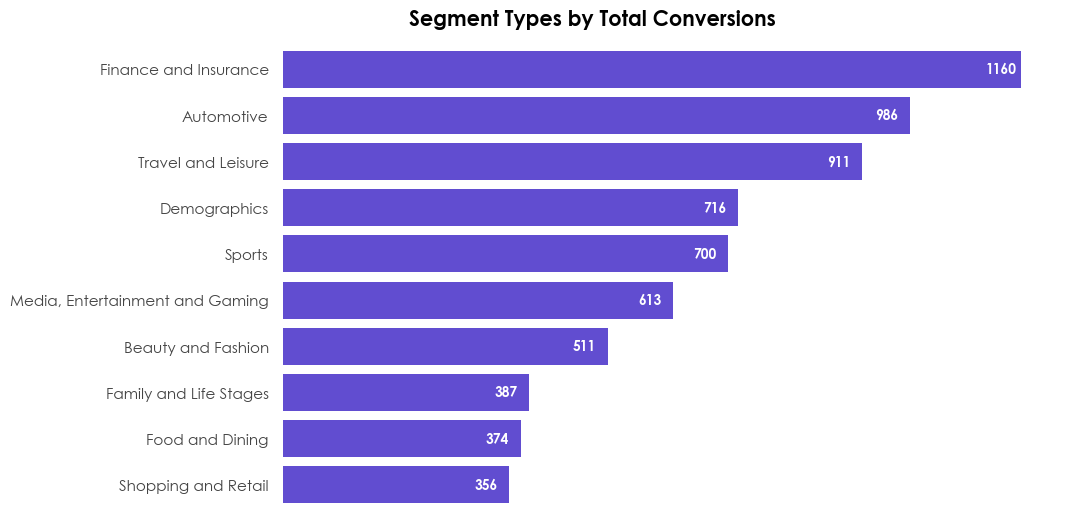

In [70]:
# Plot barchart for viewable_impressions_subset
plt.figure(figsize=(10,6))
ax = sns.barplot(x='Total Conversions', y='Segment Type', data=conversions.head(10), color='#5237e6')
for container in ax.containers:
    labels = [f'{round(val)}' for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=-25, color='white', fontweight='bold')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Segment Types by Total Conversions', x=0.4, pad=15, fontsize=15, fontweight='bold')
plt.yticks(color='#444444', fontsize=11)
sns.despine(left=True, bottom=True)
plt.show()

# Average viewability analysis

In [71]:
# Top 15 Segment Types by number of Total Viewable Impressions
viewability = df_subset[df_subset['Segment Type'] != 'Other'].groupby('Segment Type')['Viewability'].mean().sort_values(ascending=False).reset_index()
viewability 

,Segment Type,Viewability
0,"News, Politics and Society",0.6114
1,Family and Life Stages,0.5821
2,Travel and Leisure,0.5697
3,"Media, Entertainment and Gaming",0.5677
4,Food and Dining,0.5576
5,Sports,0.5573
6,Shopping and Retail,0.5424
7,Finance and Insurance,0.5398
8,Home and Real Estate,0.5261
9,Automotive,0.5242


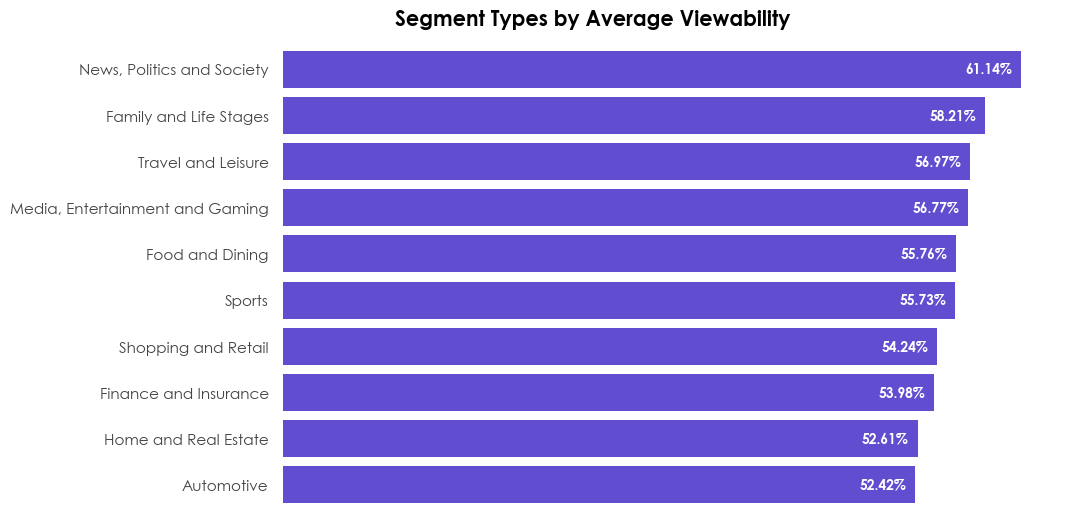

In [72]:
# Plot barchart for viewable_impressions_subset
plt.figure(figsize=(10,6))
ax = sns.barplot(x='Viewability', y='Segment Type', data=viewability.head(10), color='#5237e6')
for container in ax.containers:
    labels = [f'{val*100:.2f}%' for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=-40, color='white', fontweight='bold')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Segment Types by Average Viewability', x=0.4, pad=15, fontsize=15, fontweight='bold')
plt.yticks(color='#444444', fontsize=11)
sns.despine(left=True, bottom=True)
plt.show()

# Click Through Rate (CTR) Analysis

In [73]:
# Top Segment Types by Conversion Rate (CVR)
ctr = df_subset.groupby('Segment Type')['CTR'].mean().sort_values(ascending=False).reset_index()
ctr

,Segment Type,CTR
0,Home and Real Estate,0.0046
1,Finance and Insurance,0.0040
2,Shopping and Retail,0.0038
3,Automotive,0.0037
4,Food and Dining,0.0036
5,Demographics,0.0036
6,Beauty and Fashion,0.0036
7,"Media, Entertainment and Gaming",0.0035
8,Lifestyle and Social,0.0035
9,Family and Life Stages,0.0034


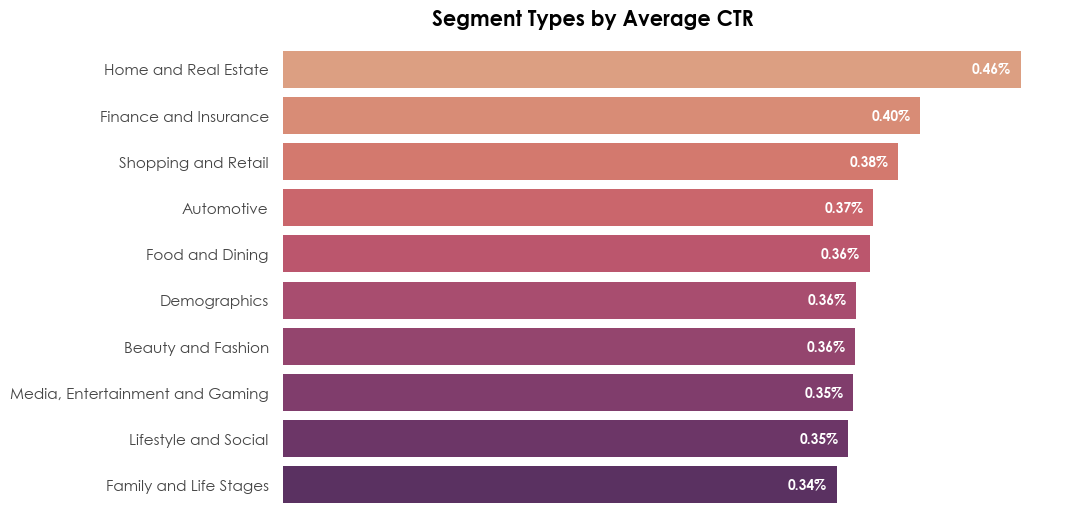

In [74]:
# Plot barchart for cvr_top
plt.figure(figsize=(10,6))
ax = sns.barplot(x='CTR', y='Segment Type', data=ctr.head(10), hue='Segment Type', palette='flare')
for container in ax.containers:
    labels = [f'{val*100:.2f}%' for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=-35, color='white', fontweight='bold')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Segment Types by Average CTR', x=0.4, pad=15, fontsize=15, fontweight='bold')
plt.yticks(color='#444444', fontsize=11)
sns.despine(left=True, bottom=True)
plt.show()

# Conversion Rate (CVR) Analysis

In [75]:
# Top Segment Types by Conversion Rate (CVR)
cvr = df_subset[df_subset['Segment Type'] != 'Other'].groupby('Segment Type')['CVR'].mean().sort_values(ascending=False).reset_index()
cvr

,Segment Type,CVR
0,Beauty and Fashion,0.1554
1,Travel and Leisure,0.1436
2,B2B and Business,0.1421
3,Sports,0.1391
4,"News, Politics and Society",0.1133
5,Technology,0.1111
6,Home and Real Estate,0.1103
7,Automotive,0.0997
8,Shopping and Retail,0.0985
9,Demographics,0.0940


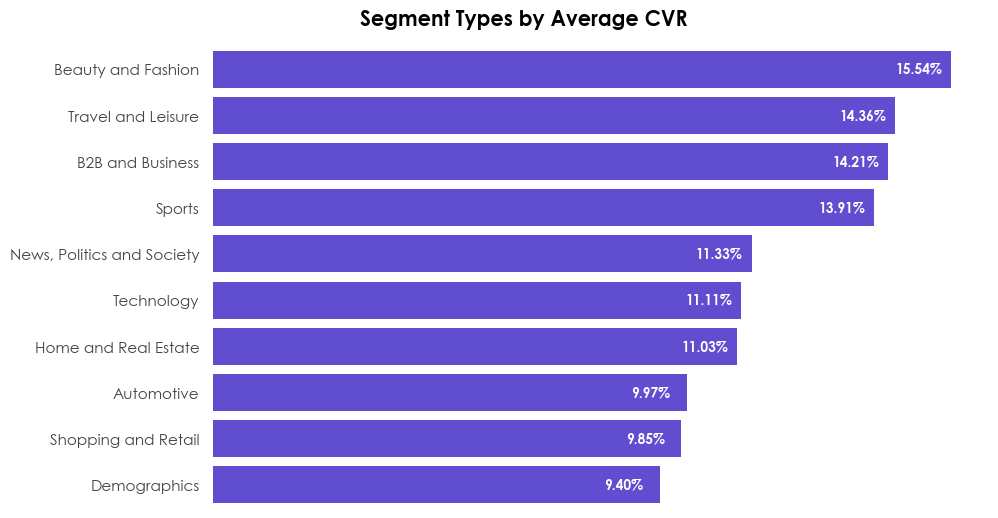

In [76]:
# Plot barchart for cvr_top
plt.figure(figsize=(10,6))
ax = sns.barplot(x='CVR', y='Segment Type', data=cvr.head(10), color='#5237e6')
for container in ax.containers:
    labels = [f'{val*100:.2f}%' for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=-40, color='white', fontweight='bold')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Segment Types by Average CVR', x=0.4, pad=15, fontsize=15, fontweight='bold')
plt.yticks(color='#444444', fontsize=11)
sns.despine(left=True, bottom=True)
plt.show()

# Cost of Acquisition (CPA) Analysis

In [77]:
# Top 10 Segment Types by Cost of Acquisition (eCPA)
cpa = df_subset[df_subset['Segment Type'] != 'Other'].groupby('Segment Type')['CPA ($)'].mean().sort_values(ascending=True).reset_index()
cpa

,Segment Type,CPA ($)
0,Pets,324.9029
1,"News, Politics and Society",457.3243
2,B2B and Business,484.7760
3,Technology,497.1282
4,Travel and Leisure,505.1893
5,Education and Careers,505.2880
6,Food and Dining,520.6382
7,Finance and Insurance,549.1742
8,Family and Life Stages,549.6767
9,Beauty and Fashion,608.6193


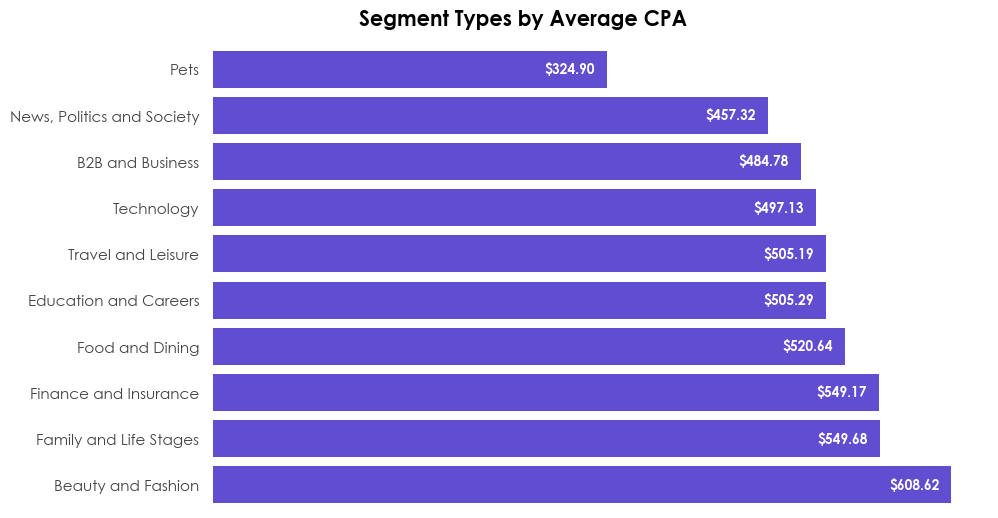

In [78]:
# Plot barchart for ecpa
plt.figure(figsize=(10,6))
ax = sns.barplot(x='CPA ($)', y='Segment Type', data=cpa.head(10), color='#5237e6')
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=-45, fmt='$%.2f', color='white', fontweight='bold')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title('Segment Types by Average CPA', x=0.4, pad=15, fontsize=15, fontweight='bold')
plt.yticks(color='#444444', fontsize=11)
sns.despine(left=True, bottom=True)
plt.show()

# Finance Audience Analysis

In [79]:
# Constructing function for analysis of top segments
def top_5(segment, var_name):
    agg = (
        segment
        .groupby(var_name)
        .agg(
            total_conv=('Total Conversions', 'sum'),
            avg_cvr=('CVR', 'mean'),
            avg_ctr=('CTR', 'mean'),
            avg_cpa=('CPA ($)', 'mean'),
            avg_viewability=('Viewability', 'mean'),
            total_vimps=('Viewable Impressions', 'sum')   
        )
    )

    metrics = [
        ('total_conv', False, 'Total Conversions'),
        ('avg_cvr', False, 'Average CVR'),
        ('avg_cpa', True,  'Average CPA'),
        ('avg_viewability', False, 'Average Viewability'),
        #('avg_ctr', False, 'Average CTR'),
    ]

    for col, asc, label in metrics:
        print(f"\n### Top {var_name}s by {label} ###")
        print(agg.sort_values(col, ascending=asc).head())

In [80]:
# Filter dataset for 'Finance' segment type
finance = df_subset[df_subset['Segment Type'] == 'Finance and Insurance']

## Segment Detail

In [81]:
top_5(finance, 'Segment Detail')


### Top Segment Details by Total Conversions ###
                         total_conv  avg_cvr  avg_ctr  avg_cpa  \
Segment Detail                                                   
Credit and Lending              154   0.1228   0.0003  52.2000   
Loans                           147   0.0493   0.0027  54.2000   
Banking                          84   0.1053   0.0057 281.0400   
Accounting and Auditing          78   0.0161   0.0027  96.4200   
Savings Accounts                 74   0.0778   0.0027  91.2400   

                         avg_viewability  total_vimps  
Segment Detail                                         
Credit and Lending                0.6788      2338732  
Loans                             0.6050       629973  
Banking                           0.6720       673075  
Accounting and Auditing           0.5684       881525  
Savings Accounts                  0.6033       203987  

### Top Segment Details by Average CVR ###
                              total_conv  avg_cvr  

## Location

In [82]:
top_5(finance, 'Location')


### Top Locations by Total Conversions ###
                               total_conv  avg_cvr  avg_ctr  avg_cpa  \
Location                                                               
Chicago, Illinois                     573   0.0804   0.0029 315.6175   
Los Angeles, California               146   0.1267   0.0045 730.0100   
New York City, New York               118   0.0813   0.0050 726.0400   
Miami-Ft. Lauderdale, Florida         110   0.0863   0.0039 230.7460   
Nashville, Tennessee                   54   0.0554   0.0057 408.5500   

                               avg_viewability  total_vimps  
Location                                                     
Chicago, Illinois                       0.5650      4643270  
Los Angeles, California                 0.5698       771219  
New York City, New York                 0.4517        94672  
Miami-Ft. Lauderdale, Florida           0.6031       976134  
Nashville, Tennessee                    0.6392       187452  

### Top Location

## App/URL

In [83]:
top_5(finance, 'App/URL')


### Top App/URLs by Total Conversions ###
                  total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
App/URL                                                                    
ebay.com                 283   0.0556   0.0025 230.3867           0.3841   
msn.com                  276   0.0373   0.0021 182.0420           0.6718   
yahoo.com                 91   0.0120   0.0028 113.1000           0.4647   
the-sun.com               74   0.0778   0.0027  91.2400           0.6033   
outlook.live.com          41   0.0438   0.0035 382.7467           0.9160   

                  total_vimps  
App/URL                        
ebay.com              1205139  
msn.com               3801941  
yahoo.com             1082678  
the-sun.com            203987  
outlook.live.com       220773  

### Top App/URLs by Average CVR ###
                                  total_conv  avg_cvr  avg_ctr  avg_cpa  \
App/URL                                                                   
newsmemory.co

## Device Make

In [84]:
top_5(finance, 'Device Make')


### Top Device Makes by Total Conversions ###
             total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
Device Make                                                           
Smartphone         1031   0.0784   0.0037 591.7775           0.5444   
Apple PC             77   0.2189   0.0056 260.1450           0.5394   
Windows PC           52   0.0884   0.0043 486.5186           0.5062   

             total_vimps  
Device Make               
Smartphone       6845722  
Apple PC          231753  
Windows PC         89557  

### Top Device Makes by Average CVR ###
             total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
Device Make                                                           
Apple PC             77   0.2189   0.0056 260.1450           0.5394   
Windows PC           52   0.0884   0.0043 486.5186           0.5062   
Smartphone         1031   0.0784   0.0037 591.7775           0.5444   

             total_vimps  
Device Make               
Apple PC   

## Summary

In [85]:
finance.describe()

,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost ($),Viewability,CTR,vCTR,CVR,CPC ($),CPM ($),CPA ($)
count,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000,64.0000
mean,212070.1562,429.6562,111984.8750,186632.0938,18.1250,3955.3848,0.5398,0.0040,0.0127,0.0926,40.4872,154.4556,549.1742
std,595991.3150,863.5825,331485.1898,507499.5228,29.6388,2572.3844,0.2112,0.0021,0.0190,0.1063,54.9794,195.8363,584.0536
min,7394.0000,20.0000,723.0000,2975.0000,1.0000,1447.9300,0.0205,0.0003,0.0005,0.0038,1.0200,1.9300,52.2000
25%,12729.0000,68.7500,5974.7500,11620.7500,4.7500,1687.2625,0.4515,0.0025,0.0051,0.0317,10.6675,37.4875,196.8950
50%,32144.0000,100.5000,13340.5000,26791.0000,9.0000,2229.6000,0.5643,0.0031,0.0081,0.0604,23.4100,104.6650,403.1950
75%,91563.7500,265.0000,47755.5000,75902.2500,15.0000,6731.8550,0.6795,0.0050,0.0140,0.1207,47.6900,169.9225,628.2950
max,4154911.0000,4852.0000,2338732.0000,3445626.0000,154.0000,8042.9000,0.9280,0.0119,0.1303,0.7000,336.3700,874.2600,3621.8000


# Travel Audience Analysis

In [86]:
# Filter dataset for 'Finance' segment type
travel = df_subset[df_subset['Segment Type'] == 'Travel and Leisure']

## Segment Detail

In [87]:
top_5(travel, 'Segment Detail')


### Top Segment Details by Total Conversions ###
                      total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
Segment Detail                                                                 
Travel                       101   0.1173   0.0024 862.2100           0.6261   
Air Travel                    89   0.5334   0.0028 117.5700           0.5717   
Tourist Destinations          55   0.0644   0.0026 143.4700           0.4609   
Africa                        44   0.0494   0.0035  33.9800           0.3503   
Theme Parks                   44   0.0481   0.0029 178.4400           0.1129   

                      total_vimps  
Segment Detail                     
Travel                     161403  
Air Travel                 151103  
Tourist Destinations       138319  
Africa                      66972  
Theme Parks                 33355  

### Top Segment Details by Average CVR ###
                                    total_conv  avg_cvr  avg_ctr  avg_cpa  \
Segment Detail  

## Location

In [88]:
top_5(travel, 'Location')


### Top Locations by Total Conversions ###
                               total_conv  avg_cvr  avg_ctr  avg_cpa  \
Location                                                               
Chicago, Illinois                     216   0.2201   0.0027 789.2777   
New York City, New York               210   0.1653   0.0026 605.4700   
Miami-Ft. Lauderdale, Florida         148   0.0873   0.0034 189.5062   
Los Angeles, California               109   0.0635   0.0038 423.5883   
San Francisco, California              63   0.0657   0.0044 601.9429   

                               avg_viewability  total_vimps  
Location                                                     
Chicago, Illinois                       0.5878       508156  
New York City, New York                 0.4951       719171  
Miami-Ft. Lauderdale, Florida           0.6744       782028  
Los Angeles, California                 0.5109      1079767  
San Francisco, California               0.4573       157441  

### Top Location

## App/URL

In [89]:
top_5(travel, 'App/URL')


### Top App/URLs by Total Conversions ###
                   total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
App/URL                                                                     
weather.com               103   0.0414   0.0031 257.2700           0.3718   
ebay.com                   92   0.0637   0.0027 178.2967           0.4689   
finance.yahoo.com          78   1.0541   0.0027  93.1400           0.6522   
cnn.com                    69   0.0938   0.0027 118.4000           0.3764   
zillow.com                 44   0.0481   0.0029 178.4400           0.1129   

                   total_vimps  
App/URL                         
weather.com             172536  
ebay.com                245098  
finance.yahoo.com        16144  
cnn.com                  89526  
zillow.com               33355  

### Top App/URLs by Average CVR ###
                   total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
App/URL                                                                 

## Device Make

In [90]:
top_5(travel, 'Device Make')


### Top Device Makes by Total Conversions ###
             total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
Device Make                                                           
Smartphone          676   0.1148   0.0033 568.6248           0.5555   
Windows PC          153   0.2557   0.0026 357.0367           0.6206   
Apple PC             82   0.2366   0.0024 215.3157           0.6198   

             total_vimps  
Device Make               
Smartphone       3367731  
Windows PC        320879  
Apple PC          238525  

### Top Device Makes by Average CVR ###
             total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
Device Make                                                           
Windows PC          153   0.2557   0.0026 357.0367           0.6206   
Apple PC             82   0.2366   0.0024 215.3157           0.6198   
Smartphone          676   0.1148   0.0033 568.6248           0.5555   

             total_vimps  
Device Make               
Windows PC 

## Summary

In [91]:
travel.describe()

,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost ($),Viewability,CTR,vCTR,CVR,CPC ($),CPM ($),CPA ($)
count,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000
mean,134332.0847,372.3390,66561.6102,119582.1864,15.4407,4181.7885,0.5697,0.0031,0.0107,0.1436,56.0446,131.5008,505.1893
std,255226.4774,723.2421,139222.1887,227771.3361,15.4432,2478.1209,0.2146,0.0016,0.0159,0.2324,112.5711,164.4291,686.2543
min,7540.0000,10.0000,866.0000,2054.0000,1.0000,1442.2300,0.0653,0.0004,0.0008,0.0041,0.7400,2.1800,33.9800
25%,16649.5000,72.0000,8930.5000,15120.5000,7.0000,1605.5300,0.4903,0.0024,0.0039,0.0394,9.7650,24.4700,166.1500
50%,48211.0000,147.0000,23052.0000,43810.0000,9.0000,4652.3700,0.6200,0.0028,0.0055,0.0739,23.4000,62.3300,303.6800
75%,151193.5000,331.5000,66856.0000,136372.5000,17.5000,6435.5700,0.7190,0.0034,0.0089,0.1191,47.3800,147.7600,589.7100
max,1720462.0000,4865.0000,940296.0000,1516537.0000,78.0000,8168.3500,0.9115,0.0103,0.1039,1.1000,785.1400,671.5700,4719.6000


# News, Politics and Society Audience Segment Analysis

In [92]:
# Filter dataset for 'Health and Wellness' segment type
news = df_subset[df_subset['Segment Type'] == 'News, Politics and Society']

## Segment Detail

In [93]:
top_5(news, 'Segment Detail')


### Top Segment Details by Total Conversions ###
                                  total_conv  avg_cvr  avg_ctr  avg_cpa  \
Segment Detail                                                            
News and Current Events                   43   0.0694   0.0034  62.4300   
Local News                                38   0.1024   0.0030 333.8133   
Politics                                  36   0.2323   0.0028 220.7900   
Current Affairs - Social Justice          31   0.0108   0.0028 251.2400   
Technology News                           21   0.0429   0.0042 326.6700   

                                  avg_viewability  total_vimps  
Segment Detail                                                  
News and Current Events                    0.7371       131164  
Local News                                 0.4878        62477  
Politics                                   0.0855         4565  
Current Affairs - Social Justice           0.7321       699834  
Technology News                   

## Location

In [94]:
top_5(news, 'Location')


### Top Locations by Total Conversions ###
                                  total_conv  avg_cvr  avg_ctr  avg_cpa  \
Location                                                                  
New York City, New York                   94   0.1268   0.0027 397.8700   
Los Angeles, California                   53   0.0942   0.0037 111.7300   
Chicago, Illinois                         31   0.1398   0.0034 774.3450   
Grand Rapids-Kalamazoo, Michigan          27   0.0996   0.0032 510.7050   
Memphis, Tennessee                        25   0.2000   0.0028 265.8000   

                                  avg_viewability  total_vimps  
Location                                                        
New York City, New York                    0.6094       755592  
Los Angeles, California                    0.7726       146751  
Chicago, Illinois                          0.6823        95882  
Grand Rapids-Kalamazoo, Michigan           0.5996        56950  
Memphis, Tennessee                      

## App/URL

In [95]:
top_5(news, 'App/URL')


### Top App/URLs by Total Conversions ###
                total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
App/URL                                                                  
nbcnews.com             45   0.0585   0.0027 460.8750           0.7357   
thesaurus.com           36   0.2323   0.0028 220.7900           0.0855   
mail.yahoo.com          31   0.0108   0.0028 251.2400           0.7321   
realtor.com             25   0.2000   0.0028 265.8000           0.4525   
calculator.net          21   0.2100   0.0027 321.6200           0.8931   

                total_vimps  
App/URL                      
nbcnews.com          145747  
thesaurus.com          4565  
mail.yahoo.com       699834  
realtor.com           17477  
calculator.net        31829  

### Top App/URLs by Average CVR ###
                    total_conv  avg_cvr  avg_ctr  avg_cpa  avg_viewability  \
App/URL                                                                      
washingtonpost.com          12   0.

## Device Make

In [96]:
top_5(news, 'Device Make')


### Top Device Makes by Total Conversions ###
             total_conv  avg_cvr  avg_ctr   avg_cpa  avg_viewability  \
Device Make                                                            
Smartphone          290   0.1172   0.0032  412.9076           0.6082   
Apple PC             12   0.1026   0.0027  545.9000           0.9114   
Windows PC            4   0.0421   0.0051 1301.5000           0.3790   

             total_vimps  
Device Make               
Smartphone       1264472  
Apple PC           36503  
Windows PC          6473  

### Top Device Makes by Average CVR ###
             total_conv  avg_cvr  avg_ctr   avg_cpa  avg_viewability  \
Device Make                                                            
Smartphone          290   0.1172   0.0032  412.9076           0.6082   
Apple PC             12   0.1026   0.0027  545.9000           0.9114   
Windows PC            4   0.0421   0.0051 1301.5000           0.3790   

             total_vimps  
Device Make               
S

## Summary

In [97]:
news.describe()

,Impressions,Clicks,Viewable Impressions,Measurable Impressions,Total Conversions,Gross Cost ($),Viewability,CTR,vCTR,CVR,CPC ($),CPM ($),CPA ($)
count,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000,23.0000
mean,91963.7826,273.3478,56845.5652,84483.3913,13.3043,4342.7535,0.6114,0.0032,0.0078,0.1133,49.6335,166.9935,457.3243
std,206636.5315,589.8276,143563.4516,195786.6879,11.3475,2553.8198,0.2135,0.0011,0.0068,0.0918,49.6229,189.6965,276.2691
min,9261.0000,20.0000,3852.0000,7382.0000,2.0000,1345.3700,0.0855,0.0020,0.0029,0.0096,2.7100,7.7100,62.4300
25%,16935.0000,56.0000,5888.5000,13958.0000,4.0000,1712.3650,0.4522,0.0027,0.0043,0.0496,15.5050,53.5500,258.5200
50%,42755.0000,111.0000,15587.0000,38621.0000,10.0000,5206.2400,0.6270,0.0028,0.0057,0.1026,44.8500,124.6400,422.8900
75%,62583.5000,174.5000,39039.0000,59113.0000,18.5000,6760.0400,0.7359,0.0034,0.0075,0.1432,55.3950,153.3150,570.2650
max,1010148.0000,2874.0000,699834.0000,955905.0000,43.0000,7948.4800,0.9256,0.0071,0.0340,0.4000,227.9900,703.0600,1301.5000
